# 03 — Split & Feature Selection

**Proyecto:** `ml_predict_income` · **Entrada:** `enigh2024_features_v2.parquet` + `candidatas_v2.csv` (de `02`)

---

## What this notebook owns

**The train/test split.** It is defined here, once, grouped by `upm`, and written to disk. Notebook 04 reads
it rather than re-deriving it. Everything below §2 happens on the **training partition only**; the test set
is touched exactly once, in §9, to report the final number.

That is the whole reason selection lives in its own notebook. Ranking features while looking at the rows you
will later evaluate on is optimistic by construction, and the optimism is invisible — the model looks good
right up until production.

| § | Output |
|---|---|
| 1 | Setup |
| 2 | **The split** — `GroupShuffleSplit` by `upm`, saved to `split_upm.csv` |
| 3 | The elicitable pool, per segment |
| 4 | Ceiling: a model on the whole pool — the number we must not sacrifice |
| 5 | **Permutation importance** on held-out folds of train (never `gain`) |
| 6 | Redundancy pruning |
| 7 | **The curve** — performance vs number of features, with the knee |
| 8 | Stability across seeds |
| 9 | Freeze the lists, evaluate once on test |
| 10 | Save `features_ocupados.json` / `features_no_ocupados.json` |

## Why grouped by `upm`

ENIGH is a **clustered sample**: households are drawn in blocks (primary sampling units), so two people in
the same `upm` are neighbours. Their incomes are correlated far beyond what their characteristics explain.
A random row-level split puts neighbours on both sides, and the model gets credit for having memorised the
block. Grouping by `upm` forces every test cluster to be one the model has never seen — the same situation
as a new user.

## Decisions carried in

- Target: `log(ingreso_mensual)`, objective **L1** → the prediction is the conditional **median**,
  back-transformed with `exp()`, no smearing.
- Headline metric: **MdAPE** (weighted), plus share within ±20%.
- Two models, routed by `tiene_trabajo_principal`.
- Budget: **~15 features** per model.


---
## 1. Setup

```bash
pip install pandas numpy matplotlib scikit-learn lightgbm pyarrow
```


In [1]:
import json
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold, GroupShuffleSplit

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(PROC_DIR / "enigh2024_features_v2.parquet")
candidatas = pd.read_csv(PROC_DIR / "candidatas_v2.csv")
eda = json.loads((PROC_DIR / "eda_v2.json").read_text(encoding="utf-8"))

TARGET = eda["target"]          # "ingreso_mensual"
print(f"entrada: {len(df):,} filas × {df.shape[1]} columnas | target = {TARGET}")
print(candidatas["veredicto"].value_counts().to_string())

entrada: 179,557 filas × 76 columnas | target = ingreso_mensual
veredicto
No preguntable    30
Directa           28
Derivada          10


In [2]:
# --------------------------------------------------------------- Parámetros
SEMILLA = 42
TEST_SIZE = 0.20
N_FOLDS = 3                       # GroupKFold dentro de train, agrupado por upm
K_OBJETIVO = 15                   # presupuesto de preguntas del formulario
K_GRID = [1, 2, 3, 4, 6, 8, 10, 12, 15, 18, 22]
SEMILLAS_ESTABILIDAD = [0, 1, 2]
UMBRAL_REDUNDANCIA = 0.80         # V de Cramér entre variables binificadas
TOLERANCIA_CURVA = 0.01           # 1 punto de MdAPE respecto al techo = "sin sacrificio"

# Submuestreo donde el costo no compra precisión: la importancia por permutación necesita
# una estimación estable del orden, no del tercer decimal; la asociación entre variables
# es estructural. Bajar esto multiplica el tiempo de corrida sin cambiar las conclusiones.
MAX_PERM = 12_000                 # filas del fold de validación usadas al permutar
MAX_ASOC = 30_000                 # filas usadas en la matriz de redundancia

SEGMENTOS = ["Ocupados", "No ocupados"]

# Parámetros del modelo de trabajo. Deliberadamente fijos y modestos:
# aquí se compara entre conjuntos de variables, no se busca el mejor modelo (eso es §04).
PARAMS = dict(objective="regression_l1", learning_rate=0.08, num_leaves=48,
              n_estimators=300, min_child_samples=40, subsample=0.8, subsample_freq=1,
              colsample_bytree=0.8, verbose=-1, n_jobs=-1)

In [3]:
# --------------------------------------------------------------- Tipos de columna
# En pandas >= 3.0 el texto llega con dtype `str` (Arrow), no `object`. Probar
# `dtype == object` lo clasifica como numérico, `to_numeric(errors="coerce")` lo vuelve
# NaN sin avisar, y la variable desaparece del modelo sin que nada falle. Se pregunta
# por lo numérico, que es estable en ambas versiones, y se verifica al final de §3.
def es_numerica(s: pd.Series) -> bool:
    return pd.api.types.is_numeric_dtype(s)


def es_categorica(s: pd.Series) -> bool:
    return not es_numerica(s)


print("pandas", pd.__version__, "| dtype de texto:", df["cve_entidad"].dtype)

pandas 3.0.2 | dtype de texto: str


In [4]:
# --------------------------------------------------------------- Paleta
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
CMAP_SEQ = mpl.colors.LinearSegmentedColormap.from_list("azul", SEQ)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Segoe UI", "Helvetica", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.labelsize": 10, "axes.labelcolor": INK2, "axes.edgecolor": AXIS,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 8,
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
})
FMT_MILES = mpl.ticker.FuncFormatter(lambda x, _=None: f"{x:,.0f}")


def guardar(fig, nombre):
    fig.savefig(FIG_DIR / f"{nombre}.png")
    return fig


# --------------------------------------------------------------- Métricas ponderadas
def wquantile(v, q, w):
    v, w = np.asarray(v, float), np.asarray(w, float)
    ok = ~np.isnan(v); v, w = v[ok], w[ok]
    o = np.argsort(v); v, w = v[o], w[o]
    return float(np.interp(q, np.cumsum(w) / w.sum(), v))


def metricas(y_pesos, pred_pesos, w):
    err = np.abs(y_pesos - pred_pesos)
    ape = err / y_pesos
    return {
        "MdAPE": round(wquantile(ape, .5, w) * 100, 2),
        "pct_20": round(float(np.average(ape <= .20, weights=w)) * 100, 2),
        "MdAE": round(wquantile(err, .5, w), 0),
        "R2_log": round(float(
            1 - np.average((np.log(y_pesos) - np.log(np.clip(pred_pesos, 1, None))) ** 2, weights=w)
            / np.average((np.log(y_pesos) - np.average(np.log(y_pesos), weights=w)) ** 2, weights=w)), 4),
    }

---
## 2. The split

One split, defined here, saved to disk. `GroupShuffleSplit` on `upm` with a fixed seed: every primary
sampling unit lands entirely on one side.

Two things are verified before going further: that no `upm` appears on both sides, and that the two
partitions look alike on the things that matter — income distribution, segment mix, geography. A grouped
split is not stratified, so this check is not a formality.


In [5]:
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEMILLA)
idx_train, idx_test = next(gss.split(df, groups=df["upm"]))

df["particion"] = "test"
df.loc[df.index[idx_train], "particion"] = "train"

upm_train = set(df.loc[df.particion == "train", "upm"])
upm_test = set(df.loc[df.particion == "test", "upm"])
assert not (upm_train & upm_test), "Hay upm en ambas particiones"

split = (df[["upm", "particion"]].drop_duplicates().sort_values("upm").reset_index(drop=True))
split.to_csv(PROC_DIR / "split_upm.csv", index=False)

print(f"upm totales      : {df['upm'].nunique():,}")
print(f"  train          : {len(upm_train):,}  ({len(idx_train):,} personas)")
print(f"  test           : {len(upm_test):,}  ({len(idx_test):,} personas)")
print(f"traslape         : {len(upm_train & upm_test)}  ← debe ser 0")
print(f"\nguardado: split_upm.csv  ({len(split):,} upm) — 04 lo lee, no lo recalcula")

upm totales      : 10,569
  train          : 8,455  (142,990 personas)
  test           : 2,114  (36,567 personas)
traslape         : 0  ← debe ser 0

guardado: split_upm.csv  (10,569 upm) — 04 lo lee, no lo recalcula


,personas,población,% ocupados,mediana ingreso,p10,p90,entidades
partición,,,,,,,
test,36567,15453177,77.900,"7,859.600","1,549.300","20,754.100",32
train,142990,61691365,77.400,"7,918.000","1,630.400","20,901.600",32


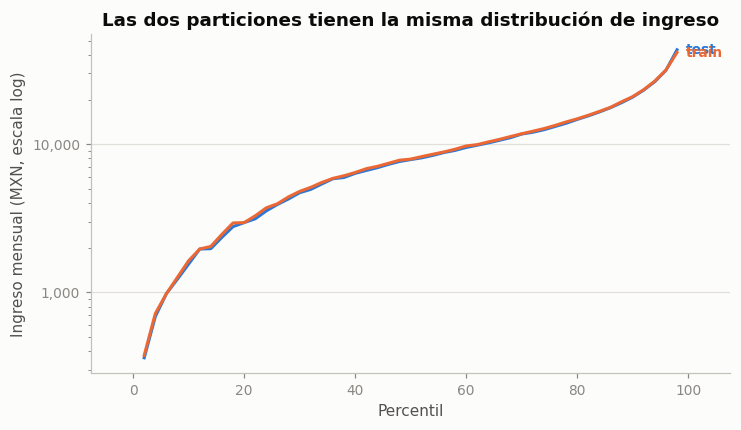

In [6]:
# ¿Se parecen las particiones?
comp = []
for p, g in df.groupby("particion"):
    comp.append({
        "partición": p, "personas": len(g), "población": g["factor"].sum(),
        "% ocupados": 100 * np.average(g["segmento"] == "Ocupados", weights=g["factor"]),
        "mediana ingreso": wquantile(g[TARGET], .5, g["factor"]),
        "p10": wquantile(g[TARGET], .10, g["factor"]),
        "p90": wquantile(g[TARGET], .90, g["factor"]),
        "entidades": g["cve_entidad"].nunique(),
    })
display(pd.DataFrame(comp).set_index("partición").round(1))

fig, ax = plt.subplots(figsize=(7.5, 4))
qs = np.linspace(.02, .98, 49)
for i, (p, g) in enumerate(df.groupby("particion")):
    y = [wquantile(g[TARGET], q, g["factor"]) for q in qs]
    ax.plot(qs * 100, y, color=SERIES[i], label=p)
    ax.annotate(p, (qs[-1] * 100, y[-1]), xytext=(6, 0), textcoords="offset points",
                color=SERIES[i], fontsize=9, va="center", fontweight="semibold")
ax.set_yscale("log")
ax.set_title("Las dos particiones tienen la misma distribución de ingreso")
ax.set_xlabel("Percentil"); ax.set_ylabel("Ingreso mensual (MXN, escala log)")
ax.yaxis.set_major_formatter(FMT_MILES)
ax.margins(x=.10)
guardar(fig, "03_split_validacion");

---
## 3. The elicitable pool, per segment

Only `Directa` and `Derivada` candidates enter. Within each segment we additionally drop anything that is
**constant** (`formalidad` is "0 No trabaja" for every non-worker) or **almost entirely missing**
(`horas_trabajadas` does not exist outside the worker segment). Those are not judgements about the variable
— they are facts about the segment, and they are what makes two models the right shape.


In [7]:
POOL_BASE = candidatas.loc[candidatas["veredicto"] != "No preguntable", "variable"].tolist()
POOL_BASE = [c for c in POOL_BASE if c != "tiene_trabajo_principal"]   # es el ruteo, no una feature
PREGUNTAS = dict(zip(candidatas["variable"], candidatas["pregunta_al_usuario"]))

tr = df[df.particion == "train"]
pools, datos = {}, {}
for seg in SEGMENTOS:
    g = tr[tr.segmento == seg]
    util, descartadas = [], []
    for c in POOL_BASE:
        if g[c].nunique(dropna=True) <= 1:
            descartadas.append((c, "constante en el segmento"))
        elif g[c].isna().mean() > .95:
            descartadas.append((c, f"{g[c].isna().mean():.0%} faltante"))
        else:
            util.append(c)
    pools[seg] = util
    print(f"\n{seg}: {len(util)} variables útiles de {len(POOL_BASE)}")
    for c, motivo in descartadas:
        print(f"    − {c:<26} {motivo}")


Ocupados: 36 variables útiles de 37
    − actividad_no_ocupado       constante en el segmento

No ocupados: 20 variables útiles de 37
    − sinco_grupo                constante en el segmento
    − tiene_contrato_escrito     constante en el segmento
    − formalidad                 constante en el segmento
    − contrato_indefinido        constante en el segmento
    − horas_trabajadas           constante en el segmento
    − tam_empresa_grupo          constante en el segmento
    − clase_empleador            constante en el segmento
    − sector_agrupado            constante en el segmento
    − jornada                    constante en el segmento
    − posicion_ocupacion         constante en el segmento
    − n_trabajos                 constante en el segmento
    − tiene_trabajo_secundario   constante en el segmento
    − n_prestaciones             constante en el segmento
    − tam_empresa                constante en el segmento
    − empleo_formal              constante en el segm

In [8]:
def preparar(sub, cols):
    """Tipado para LightGBM: categóricas como `category`, el resto numérico.

    `pd.to_numeric` va SIN errors="coerce" a propósito: si una categórica se colara
    por esta rama, queremos que truene aquí y no que se convierta en una columna de
    NaN que el modelo ignora en silencio."""
    X = sub[cols].copy()
    for c in cols:
        if es_categorica(X[c]):
            X[c] = X[c].astype(str).astype("category")
        else:
            X[c] = pd.to_numeric(X[c]).astype("float64")
    return X


for seg in SEGMENTOS:
    sub = df[df.segmento == seg]
    datos[seg] = {
        "X": preparar(sub, pools[seg]),
        "y": np.log(sub[TARGET].clip(lower=1)).to_numpy(),
        "y_pesos": sub[TARGET].to_numpy(),
        "w": sub["factor"].to_numpy(),
        "upm": sub["upm"].to_numpy(),
        "es_train": (sub["particion"] == "train").to_numpy(),
    }
    d = datos[seg]
    n_cat = sum(str(d["X"][c].dtype) == "category" for c in d["X"].columns)
    vacias = [c for c in d["X"].columns if d["X"][c].isna().all()]
    assert not vacias, f"{seg}: columnas vacías tras el tipado — {vacias}"
    print(f"{seg:<12} train={d['es_train'].sum():>7,}  test={(~d['es_train']).sum():>6,}  "
          f"features={d['X'].shape[1]}  (categóricas={n_cat}, ninguna vacía)")

Ocupados     train=110,743  test=28,428  features=36  (categóricas=12, ninguna vacía)
No ocupados  train= 32,247  test= 8,139  features=20  (categóricas=5, ninguna vacía)


---
## 4. The ceiling

Before cutting anything: how good is a model on the **whole elicitable pool**? That is the number §7 must
not sacrifice. Evaluated by `GroupKFold` inside train — the test set stays sealed.


In [9]:
def cv_evaluar(seg, cols, semilla=0, n_folds=N_FOLDS):
    """MdAPE fuera de fold, dentro de train, agrupando por upm."""
    d = datos[seg]
    X = d["X"].loc[d["es_train"], cols]
    y, yp, w, g = d["y"][d["es_train"]], d["y_pesos"][d["es_train"]], d["w"][d["es_train"]], d["upm"][d["es_train"]]
    pred = np.empty(len(X))
    for tr_i, va_i in GroupKFold(n_splits=n_folds).split(X, y, groups=g):
        m = lgb.LGBMRegressor(**PARAMS, random_state=semilla)
        m.fit(X.iloc[tr_i], y[tr_i])
        pred[va_i] = m.predict(X.iloc[va_i])
    return metricas(yp, np.exp(pred), w), pred


techos = {}
for seg in SEGMENTOS:
    techos[seg], _ = cv_evaluar(seg, pools[seg])
    print(f"{seg:<12} k={len(pools[seg]):>2}  {techos[seg]}")
print("\nEste es el techo del pool preguntable. La selección debe acercarse a él con ~15 variables.")

Ocupados     k=36  {'MdAPE': 29.22, 'pct_20': 36.27, 'MdAE': 2375.0, 'R2_log': 0.5353}


No ocupados  k=20  {'MdAPE': 41.98, 'pct_20': 25.75, 'MdAE': 1460.0, 'R2_log': 0.4795}

Este es el techo del pool preguntable. La selección debe acercarse a él con ~15 variables.


---
## 5. Permutation importance

Ranking by LightGBM's `gain` would be a mistake here: gain is biased toward high-cardinality splits, which
is exactly how the earlier benchmark ended up ranking a 477-level occupation code above everything else,
for no real predictive gain.

**Permutation importance** asks a fairer question: shuffle one column in the *held-out* fold and measure how
much worse the prediction gets. A variable that only helped the model memorise the training rows scores
zero. It is more expensive, and it is the right expense.

The importance below is measured on out-of-fold data inside train, averaged over the folds.


In [10]:
def importancia_permutacion(seg, cols, semilla=0, n_repeats=2, n_folds=2):
    d = datos[seg]
    X = d["X"].loc[d["es_train"], cols]
    y, g = d["y"][d["es_train"]], d["upm"][d["es_train"]]
    rng = np.random.RandomState(semilla)
    acum = np.zeros(len(cols))
    for tr_i, va_i in GroupKFold(n_splits=n_folds).split(X, y, groups=g):
        m = lgb.LGBMRegressor(**PARAMS, random_state=semilla)
        m.fit(X.iloc[tr_i], y[tr_i])
        if len(va_i) > MAX_PERM:      # permutar es predecir len(cols)*n_repeats veces
            va_i = rng.choice(va_i, MAX_PERM, replace=False)
        pi = permutation_importance(m, X.iloc[va_i], y[va_i], n_repeats=n_repeats,
                                    random_state=semilla, n_jobs=-1,
                                    scoring="neg_mean_absolute_error")
        acum += pi.importances_mean
    return pd.Series(acum / n_folds, index=cols).sort_values(ascending=False)


importancias = {seg: importancia_permutacion(seg, pools[seg]) for seg in SEGMENTOS}
for seg in SEGMENTOS:
    print(f"\n=== {seg} — top 12 (aumento del MAE en log al permutar) ===")
    print(importancias[seg].head(12).round(4).to_string())


=== Ocupados — top 12 (aumento del MAE en log al permutar) ===
horas_trabajadas     0.042
n_prestaciones       0.040
cve_entidad          0.031
anios_escolaridad    0.028
sinco_grupo          0.022
posicion_ocupacion   0.019
es_jefe_hogar        0.018
scian_sector         0.015
es_mujer             0.011
tam_empresa          0.011
edad                 0.010
n_trabajos           0.005

=== No ocupados — top 12 (aumento del MAE en log al permutar) ===
actividad_no_ocupado      0.214
es_jefe_hogar             0.076
anios_escolaridad         0.054
edad                      0.041
experiencia_potencial     0.015
cve_entidad               0.012
integrantes_hogar         0.008
situacion_conyugal        0.006
cotiza_seguridad_social   0.006
hijos_sobrevivientes      0.004
tiene_discapacidad        0.003
tamanio_localidad         0.001


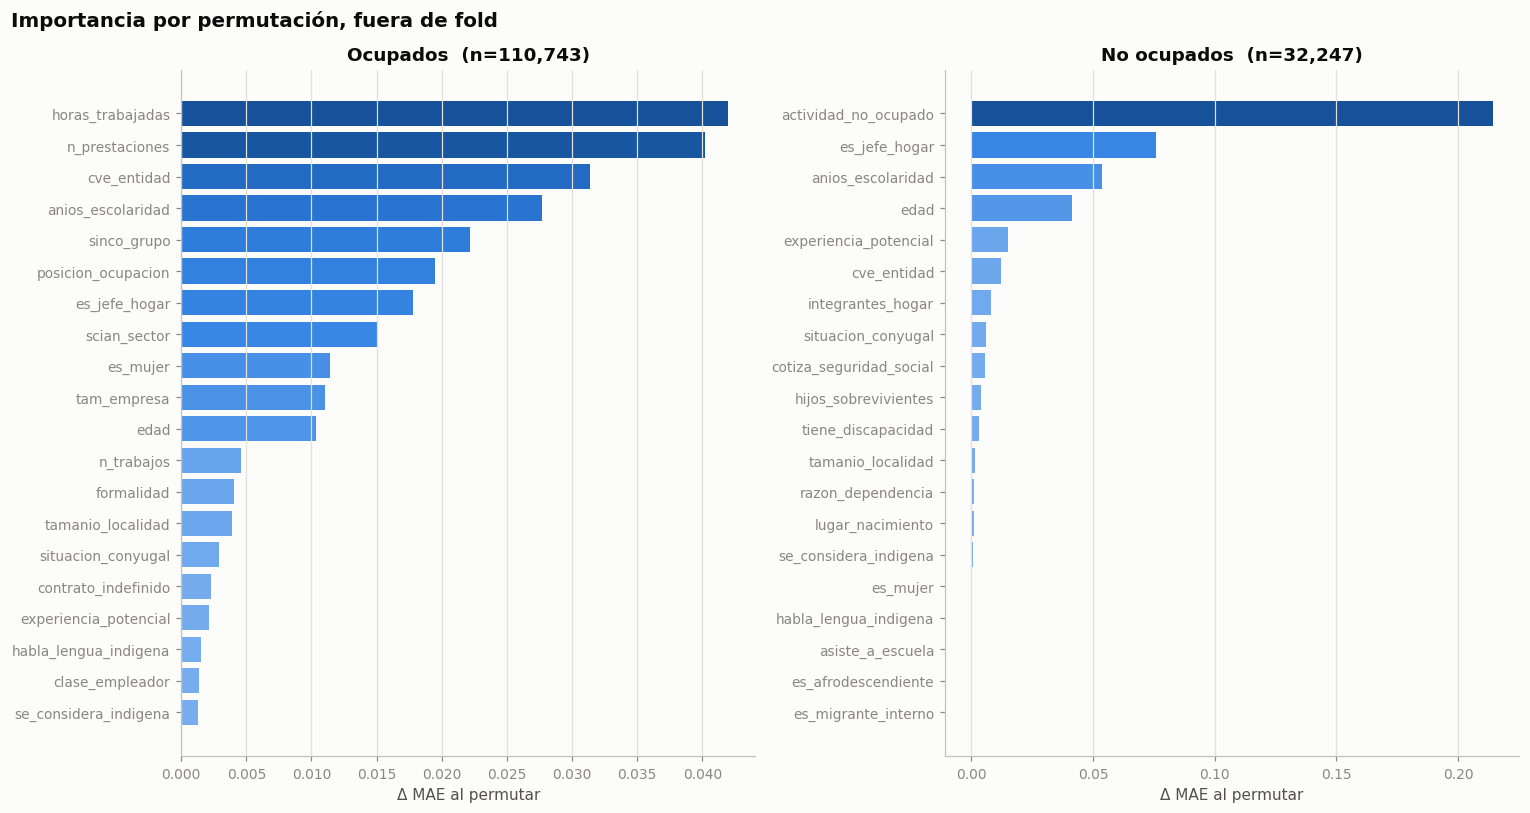

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7.5))
for ax, seg in zip(axes, SEGMENTOS):
    t = importancias[seg].head(20).iloc[::-1]
    norm = (t - t.min()) / (t.max() - t.min() + 1e-9)
    ax.barh(np.arange(len(t)), t.values, color=CMAP_SEQ(.30 + .60 * norm.values))
    ax.set_yticks(np.arange(len(t))); ax.set_yticklabels(t.index)
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.set_title(f"{seg}  (n={datos[seg]['es_train'].sum():,})")
    ax.set_xlabel("Δ MAE al permutar")
fig.suptitle("Importancia por permutación, fuera de fold", x=0.01, ha="left",
             fontsize=13, fontweight="semibold")
fig.tight_layout()
guardar(fig, "03_importancia");

---
## 6. Redundancy pruning

Importance is measured one variable at a time, so two variables carrying the same information both score
well and both look essential. Notebook 02 built several such pairs on purpose — `horas_trabajadas` vs
`jornada`, `tam_empresa` vs `tam_empresa_grupo`, the four formality columns — precisely so this step could
choose between them rather than guessing earlier.

The rule: walk the ranking from the top; a candidate is dropped when its association with an
already-kept variable exceeds `UMBRAL_REDUNDANCIA`. Association is **Cramér's V over binned versions of both
variables**, which treats numeric and categorical identically and catches non-linear equivalence that
correlation would miss.

The better-ranked variable wins — but the loser is recorded, because when the winner is
`horas_trabajadas` (a number the user must recall) and the loser is `jornada` (three buttons), the product
may prefer the loser. §7 measures that trade instead of assuming it.


In [12]:
from scipy.stats import chi2_contingency


def binificar(s, k=10):
    if es_categorica(s):
        return s.astype(str).fillna("__NA__")
    s = pd.to_numeric(s, errors="coerce")
    if s.nunique(dropna=True) <= k:
        return s.astype(str)
    b = pd.qcut(s, k, duplicates="drop")
    return (s.astype(str) if b.nunique(dropna=True) < 2 else b.astype(str))


def cramers_v(a, b):
    t = pd.crosstab(a, b)
    if min(t.shape) < 2:
        return 0.0
    chi2 = chi2_contingency(t, correction=False)[0]
    return float(np.sqrt((chi2 / t.to_numpy().sum()) / (min(t.shape) - 1)))


def podar_redundantes(seg, umbral=UMBRAL_REDUNDANCIA):
    d = datos[seg]
    X = d["X"].loc[d["es_train"]]
    if len(X) > MAX_ASOC:
        X = X.sample(MAX_ASOC, random_state=SEMILLA)
    binned = {c: binificar(X[c]) for c in X.columns}
    orden = importancias[seg].index.tolist()
    conservadas, descartes = [], []
    for c in orden:
        choque = None
        for k in conservadas:
            v = cramers_v(binned[c], binned[k])
            if v > umbral:
                choque = (k, round(v, 3))
                break
        if choque:
            descartes.append({"descartada": c, "redundante_con": choque[0], "V": choque[1],
                              "imp_descartada": round(importancias[seg][c], 4),
                              "imp_conservada": round(importancias[seg][choque[0]], 4)})
        else:
            conservadas.append(c)
    return conservadas, pd.DataFrame(descartes)


podados, descartes_red = {}, {}
for seg in SEGMENTOS:
    podados[seg], descartes_red[seg] = podar_redundantes(seg)
    print(f"\n=== {seg}: {len(pools[seg])} → {len(podados[seg])} tras podar redundancia ===")
    if len(descartes_red[seg]):
        display(descartes_red[seg])
    else:
        print("    (ningún par por encima del umbral)")


=== Ocupados: 36 → 29 tras podar redundancia ===


,descartada,redundante_con,V,imp_descartada,imp_conservada
0,sector_agrupado,scian_sector,1.000,0.001,0.015
1,jornada,horas_trabajadas,0.985,0.001,0.042
2,cotiza_seguridad_social,formalidad,0.971,0.001,0.004
3,empleo_formal,n_prestaciones,0.901,0.000,0.040
4,tam_empresa_grupo,tam_empresa,1.000,0.000,0.011
5,tiene_trabajo_secundario,n_trabajos,1.000,0.000,0.005
6,es_migrante_interno,lugar_nacimiento,1.000,0.000,0.001



=== No ocupados: 20 → 18 tras podar redundancia ===


,descartada,redundante_con,V,imp_descartada,imp_conservada
0,asiste_a_escuela,actividad_no_ocupado,0.884,0.000,0.214
1,es_migrante_interno,lugar_nacimiento,1.000,-0.000,0.001


---
## 7. The curve

Greedy forward selection along the pruned ranking: fit with the top 1, the top 2, … and measure out-of-fold
MdAPE inside train. The result answers the actual product question — *how much accuracy does each additional
question buy?* — instead of picking a number of features by feel.

The **knee** is marked at the smallest `k` whose MdAPE is within `TOLERANCIA_CURVA` (1 percentage point) of
the full-pool ceiling. That is the operational definition of "without heavily sacrificing performance".


In [13]:
curvas = {}
for seg in SEGMENTOS:
    filas = []
    for k in [k for k in K_GRID if k <= len(podados[seg])]:
        m, _ = cv_evaluar(seg, podados[seg][:k])
        filas.append({"k": k, **m})
        print(f"{seg:<12} k={k:>2}  MdAPE={m['MdAPE']:>5.2f}%  ±20%={m['pct_20']:>5.2f}%  R2log={m['R2_log']:.4f}")
    curvas[seg] = pd.DataFrame(filas)
    print()

Ocupados     k= 1  MdAPE=41.25%  ±20%=25.10%  R2log=0.1931


Ocupados     k= 2  MdAPE=37.56%  ±20%=28.11%  R2log=0.3077


Ocupados     k= 3  MdAPE=36.19%  ±20%=29.10%  R2log=0.3368


Ocupados     k= 4  MdAPE=34.17%  ±20%=30.85%  R2log=0.3926


Ocupados     k= 6  MdAPE=32.46%  ±20%=32.84%  R2log=0.4477


...

No ocupados  k= 8  MdAPE=42.48%  ±20%=25.53%  R2log=0.4710


No ocupados  k=10  MdAPE=41.55%  ±20%=26.12%  R2log=0.4756


No ocupados  k=12  MdAPE=41.94%  ±20%=26.00%  R2log=0.4804


No ocupados  k=15  MdAPE=41.93%  ±20%=25.87%  R2log=0.4790


No ocupados  k=18  MdAPE=42.28%  ±20%=25.83%  R2log=0.4791



Ocupados: rodilla en k=10 (techo 29.22% con 29 vars, k=15 → 29.14%)
No ocupados: rodilla en k=8 (techo 41.98% con 18 vars, k=15 → 41.93%)


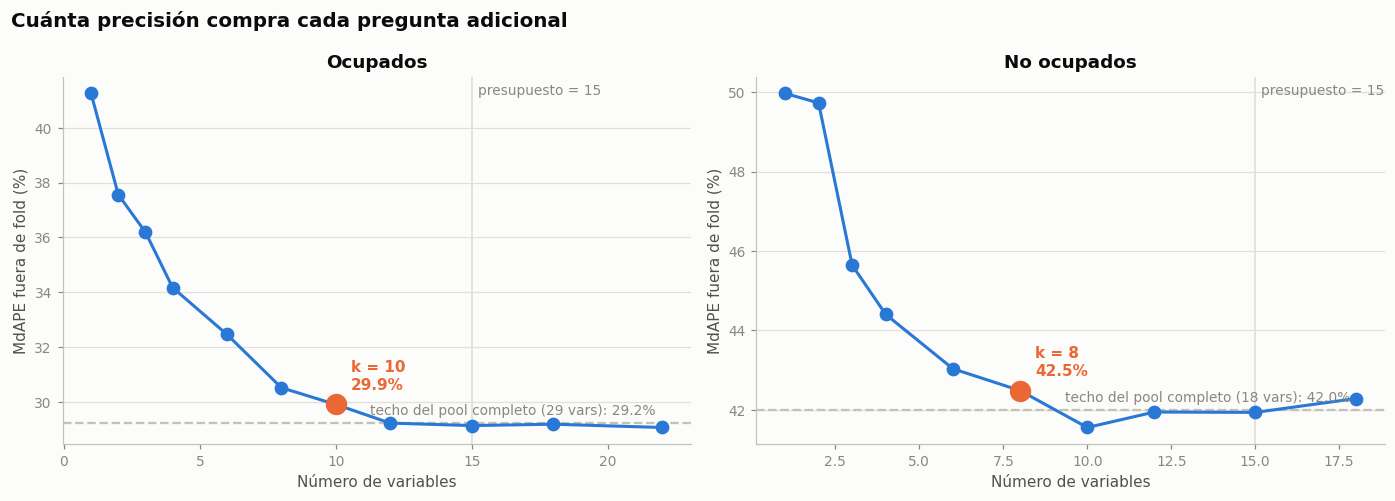

In [14]:
rodillas = {}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=False)
for ax, seg in zip(axes, SEGMENTOS):
    c = curvas[seg]
    techo = techos[seg]["MdAPE"]
    objetivo = techo + TOLERANCIA_CURVA * 100
    elegible = c[c["MdAPE"] <= objetivo]
    k_rodilla = int(elegible["k"].min()) if len(elegible) else int(c.loc[c["MdAPE"].idxmin(), "k"])
    rodillas[seg] = k_rodilla

    ax.axhline(techo, color=AXIS, linewidth=1.5, linestyle="--")
    ax.annotate(f"techo del pool completo ({len(podados[seg])} vars): {techo:.1f}%",
                (c["k"].max(), techo), xytext=(-4, 6), textcoords="offset points",
                ha="right", color=MUTED, fontsize=9)
    ax.plot(c["k"], c["MdAPE"], color=SERIES[0], marker="o")
    y_rod = float(c.loc[c["k"] == k_rodilla, "MdAPE"].iloc[0])
    ax.plot([k_rodilla], [y_rod], marker="o", markersize=13, color=SERIES[1], zorder=5)
    ax.annotate(f"k = {k_rodilla}\n{y_rod:.1f}%", (k_rodilla, y_rod), xytext=(10, 10),
                textcoords="offset points", color=SERIES[1], fontsize=10, fontweight="semibold")
    ax.axvline(K_OBJETIVO, color=GRID, linewidth=1.2, zorder=0)
    ax.annotate("presupuesto = 15", (K_OBJETIVO, ax.get_ylim()[1]), xytext=(4, -12),
                textcoords="offset points", color=MUTED, fontsize=9)
    ax.set_title(seg); ax.set_xlabel("Número de variables"); ax.set_ylabel("MdAPE fuera de fold (%)")
fig.suptitle("Cuánta precisión compra cada pregunta adicional", x=0.01, ha="left",
             fontsize=13, fontweight="semibold")
fig.tight_layout()
guardar(fig, "03_curva_seleccion")

for seg in SEGMENTOS:
    c = curvas[seg]
    print(f"{seg}: rodilla en k={rodillas[seg]} "
          f"(techo {techos[seg]['MdAPE']:.2f}% con {len(podados[seg])} vars, "
          f"k=15 → {float(c.loc[c['k'] == 15, 'MdAPE'].iloc[0]) if 15 in set(c['k']) else float('nan'):.2f}%)")

In [15]:
# ¿Cuánto cuesta preferir la versión preguntable sobre la cruda?
INTERCAMBIOS = [("horas_trabajadas", "jornada"), ("tam_empresa", "tam_empresa_grupo"),
                ("scian_sector", "sector_agrupado"),
                ("n_prestaciones", "formalidad"), ("cve_entidad", "tamanio_localidad")]

filas = []
for seg in SEGMENTOS:
    base = podados[seg][:K_OBJETIVO]
    m_base, _ = cv_evaluar(seg, base)
    for cruda, amable in INTERCAMBIOS:
        if cruda not in base or amable not in pools[seg] or amable in base:
            continue
        alt = [amable if c == cruda else c for c in base]
        m_alt, _ = cv_evaluar(seg, alt)
        filas.append({"segmento": seg, "sale": cruda, "entra": amable,
                      "MdAPE_base": m_base["MdAPE"], "MdAPE_alt": m_alt["MdAPE"],
                      "costo_pp": round(m_alt["MdAPE"] - m_base["MdAPE"], 2)})
intercambios = pd.DataFrame(filas)
if len(intercambios):
    display(intercambios)
    print("Costo en puntos porcentuales de MdAPE por usar la variable más fácil de preguntar.\n"
          "Menos de ~0.5 pp es un intercambio que vale la pena en producto.")
else:
    print("La poda de §6 ya resolvió todos los pares; no queda intercambio que medir.")

,segmento,sale,entra,MdAPE_base,MdAPE_alt,costo_pp
0,Ocupados,horas_trabajadas,jornada,29.140,29.710,0.570
1,Ocupados,tam_empresa,tam_empresa_grupo,29.140,29.230,0.090
2,Ocupados,scian_sector,sector_agrupado,29.140,29.310,0.170


Costo en puntos porcentuales de MdAPE por usar la variable más fácil de preguntar.
Menos de ~0.5 pp es un intercambio que vale la pena en producto.


---
## 8. Stability

A ranking produced by one seed is one draw. If a variable's place in the top-k depends on the random state,
it does not belong in a list we are about to freeze into a product. The ranking is recomputed over
`SEMILLAS_ESTABILIDAD` and we keep how often each variable lands in the top-k.

Anything that misses the top-k in more than one run is flagged: it is not automatically dropped, but it is
not something to ship without looking at it.


In [16]:
K_FINAL = {seg: min(rodillas[seg], K_OBJETIVO) for seg in SEGMENTOS}
print("k final por segmento (rodilla acotada por el presupuesto):", K_FINAL)

estabilidad = {}
for seg in SEGMENTOS:
    conteo = pd.Series(0, index=podados[seg], dtype=int)
    for s in SEMILLAS_ESTABILIDAD:
        imp_s = importancia_permutacion(seg, podados[seg], semilla=s)
        conteo[imp_s.head(K_FINAL[seg]).index] += 1
    estabilidad[seg] = conteo.sort_values(ascending=False)
    print(f"\n=== {seg} — veces en el top-{K_FINAL[seg]} sobre {len(SEMILLAS_ESTABILIDAD)} semillas ===")
    print(estabilidad[seg][estabilidad[seg] > 0].to_string())

k final por segmento (rodilla acotada por el presupuesto): {'Ocupados': 10, 'No ocupados': 8}



=== Ocupados — veces en el top-10 sobre 3 semillas ===
horas_trabajadas      3
n_prestaciones        3
cve_entidad           3
anios_escolaridad     3
sinco_grupo           3
posicion_ocupacion    3
es_jefe_hogar         3
scian_sector          3
tam_empresa           3
edad                  2
es_mujer              1



=== No ocupados — veces en el top-8 sobre 3 semillas ===
actividad_no_ocupado       3
es_jefe_hogar              3
anios_escolaridad          3
edad                       3
experiencia_potencial      3
cve_entidad                3
integrantes_hogar          3
cotiza_seguridad_social    2
situacion_conyugal         1


Ocupados: 1 variables inestables dentro del top-10 → ['es_mujer']
No ocupados: 1 variables inestables dentro del top-8 → ['situacion_conyugal']


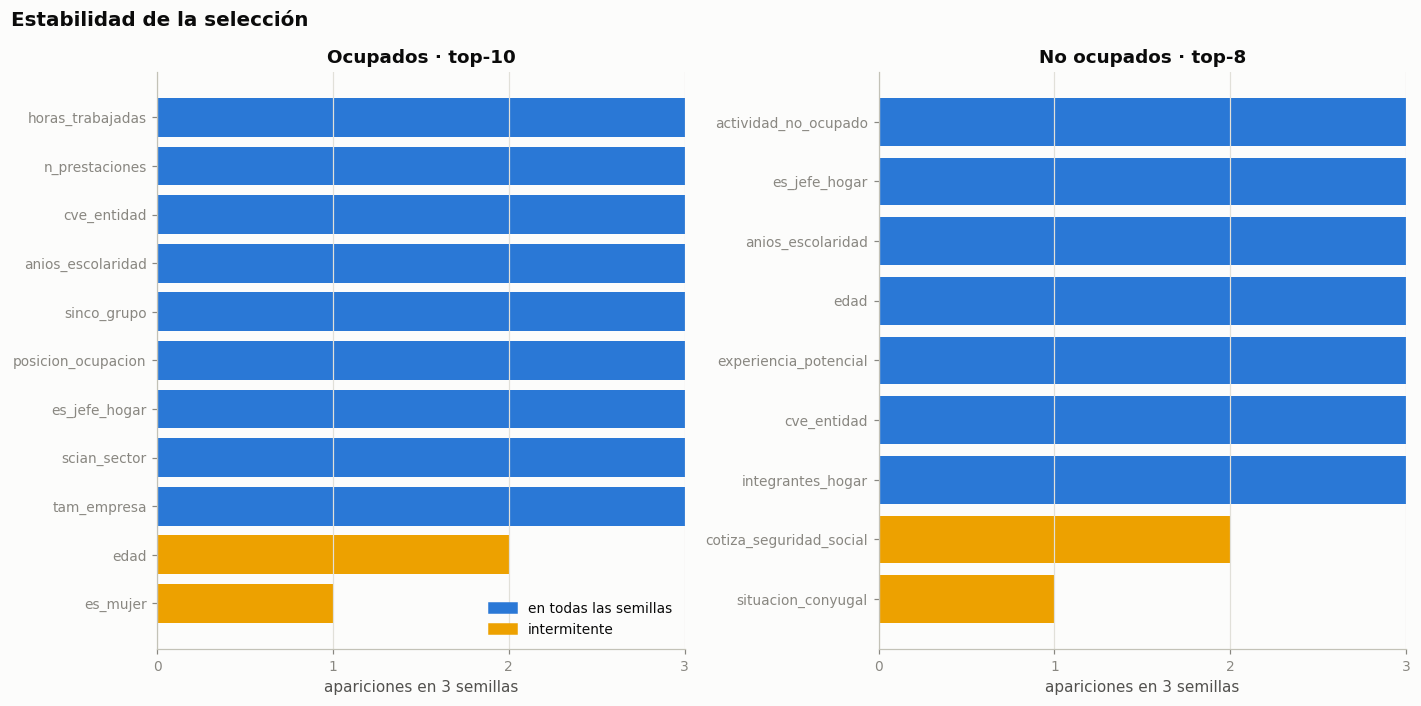

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, seg in zip(axes, SEGMENTOS):
    t = estabilidad[seg][estabilidad[seg] > 0].iloc[::-1]
    n = len(SEMILLAS_ESTABILIDAD)
    colores = [SERIES[0] if v >= n else SERIES[3] for v in t.values]
    ax.barh(np.arange(len(t)), t.values, color=colores)
    ax.set_yticks(np.arange(len(t))); ax.set_yticklabels(t.index)
    ax.set_xlim(0, n); ax.set_xticks(range(n + 1))
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.set_title(f"{seg} · top-{K_FINAL[seg]}")
    ax.set_xlabel(f"apariciones en {n} semillas")
axes[0].legend(handles=[Patch(color=SERIES[0], label="en todas las semillas"),
                        Patch(color=SERIES[3], label="intermitente")], loc="lower right")
fig.suptitle("Estabilidad de la selección", x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
guardar(fig, "03_estabilidad")

for seg in SEGMENTOS:
    inest = [c for c in podados[seg][:K_FINAL[seg]]
             if estabilidad[seg][c] < len(SEMILLAS_ESTABILIDAD)]
    print(f"{seg}: {len(inest)} variables inestables dentro del top-{K_FINAL[seg]}"
          + (f" → {inest}" if inest else ""))

---
## 8.5 Product overrides

Two things the ranking cannot know, applied **after** selection and **before** the test set is opened, each
with its cost measured by the same cross-validation:

1. **Substitutions.** Some winners are `Derivada` — real signal, but not a question a person can answer.
   `n_prestaciones` ("how many of these 19 benefits do you get?"), `tam_empresa` (an 11-point scale) and
   `scian_sector` (23 SCIAN sectors) are replaced by `formalidad`, `tam_empresa_grupo` and `sector_agrupado`
   **if** the swap costs less than `COSTO_MAXIMO_PP`. `horas_trabajadas` and `cve_entidad` are deliberately
   *not* on this list — their friendly substitutes were measured well above the threshold.

   After this step every feature in the frozen list has a real question behind it. That is the invariant:
   a model that needs an input nobody can supply is not deployable, whatever its metrics say.

2. **Derived redundancy.** `experiencia_potencial` is exactly `edad − anios_escolaridad − 6`. When both of
   its inputs are already selected it carries no independent information, and a tree model can reconstruct
   it. It is dropped rather than replaced — one question fewer, not one question swapped.

Everything here is declarative and measured, so the reasoning survives in the notebook instead of living in
a hand-edited JSON.


In [18]:
# Sustituciones: variable seleccionada -> versión preguntable
SUSTITUCIONES = {"n_prestaciones": "formalidad", "tam_empresa": "tam_empresa_grupo",
                 "scian_sector": "sector_agrupado"}
COSTO_MAXIMO_PP = 0.60      # pp de MdAPE que vale la pena pagar por una pregunta clara

# Variables que son función determinista de otras: se quitan si sus insumos ya están dentro
REDUNDANTES_DERIVADAS = {"experiencia_potencial": {"edad", "anios_escolaridad"}}

seleccion, bitacora = {}, []
for seg in SEGMENTOS:
    lista = podados[seg][:K_FINAL[seg]]
    m_base, _ = cv_evaluar(seg, lista)

    # (a) quitar derivadas redundantes
    for var, insumos in REDUNDANTES_DERIVADAS.items():
        if var in lista and insumos <= set(lista):
            alt = [c for c in lista if c != var]
            m_alt, _ = cv_evaluar(seg, alt)
            bitacora.append({"segmento": seg, "acción": "quitar", "variable": var,
                             "por": f"= f({', '.join(sorted(insumos))})",
                             "MdAPE_antes": m_base["MdAPE"], "MdAPE_después": m_alt["MdAPE"],
                             "costo_pp": round(m_alt["MdAPE"] - m_base["MdAPE"], 2),
                             "aplicado": True})
            lista, m_base = alt, m_alt

    # (b) sustituir crudas por preguntables, si el costo lo permite
    for cruda, amable in SUSTITUCIONES.items():
        if cruda not in lista or amable in lista or amable not in pools[seg]:
            continue
        alt = [amable if c == cruda else c for c in lista]
        m_alt, _ = cv_evaluar(seg, alt)
        costo = round(m_alt["MdAPE"] - m_base["MdAPE"], 2)
        aplica = costo <= COSTO_MAXIMO_PP
        bitacora.append({"segmento": seg, "acción": "sustituir", "variable": cruda,
                         "por": amable, "MdAPE_antes": m_base["MdAPE"],
                         "MdAPE_después": m_alt["MdAPE"], "costo_pp": costo, "aplicado": aplica})
        if aplica:
            lista, m_base = alt, m_alt

    seleccion[seg] = lista
    print(f"{seg:<12} k {K_FINAL[seg]} → {len(lista)}   MdAPE CV {m_base['MdAPE']:.2f}%")

display(pd.DataFrame(bitacora))

# Invariante: toda variable congelada tiene una pregunta real detrás
derivadas = {c: PREGUNTAS.get(c, "") for seg in SEGMENTOS for c in seleccion[seg]
             if candidatas.set_index("variable").loc[c, "veredicto"] == "Derivada"}
print("\nVariables 'Derivada' que sobreviven (deben ser calculables sin preguntar nada extra):")
for c, q in derivadas.items():
    print(f"  {c:<22} {q}")

Ocupados     k 10 → 10   MdAPE CV 30.54%


No ocupados  k 8 → 7   MdAPE CV 42.07%


,segmento,acción,variable,por,MdAPE_antes,MdAPE_después,costo_pp,aplicado
0,Ocupados,sustituir,n_prestaciones,formalidad,29.910,30.400,0.490,True
1,Ocupados,sustituir,tam_empresa,tam_empresa_grupo,30.400,30.450,0.050,True
2,Ocupados,sustituir,scian_sector,sector_agrupado,30.450,30.540,0.090,True
3,No ocupados,quitar,experiencia_potencial,"= f(anios_escolaridad, edad)",42.480,42.070,-0.410,True



Variables 'Derivada' que sobreviven (deben ser calculables sin preguntar nada extra):
  cve_entidad            Estado de residencia — de la ubicación o del código postal


---
## 9. Freeze the lists, then open the test set

The final lists are the top-`k` of the pruned ranking. Only now is the test partition used, once, to
produce the number that goes in the model card. Two models are scored on it: the frozen short list and the
full elicitable pool, so the cost of the reduction is stated rather than implied.

Anything below this line that looks disappointing must **not** be fixed by going back and re-selecting —
that would turn the test set into a validation set. If the short list underperforms, the honest move is to
change the plan and re-split with a new seed.


In [19]:
FEATURES = {seg: seleccion[seg] for seg in SEGMENTOS}   # ya con los overrides de §8.5

resultados = {}
for seg in SEGMENTOS:
    d = datos[seg]
    tr_m, te_m = d["es_train"], ~d["es_train"]
    fila = {}
    for etiqueta, cols in [("corta", FEATURES[seg]), ("pool completo", podados[seg])]:
        m = lgb.LGBMRegressor(**PARAMS, random_state=SEMILLA)
        m.fit(d["X"].loc[tr_m, cols], d["y"][tr_m])
        pred = np.exp(m.predict(d["X"].loc[te_m, cols]))
        fila[etiqueta] = {"k": len(cols), **metricas(d["y_pesos"][te_m], pred, d["w"][te_m])}
        if etiqueta == "corta":
            d["pred_test"] = pred
    resultados[seg] = fila

for seg in SEGMENTOS:
    print(f"\n=== {seg} — TEST (se abre una sola vez) ===")
    display(pd.DataFrame(resultados[seg]).T)
    corta, completo = resultados[seg]["corta"], resultados[seg]["pool completo"]
    print(f"Reducir de {completo['k']} a {corta['k']} variables cuesta "
          f"{corta['MdAPE'] - completo['MdAPE']:+.2f} pp de MdAPE.")


=== Ocupados — TEST (se abre una sola vez) ===


,k,MdAPE,pct_20,MdAE,R2_log
corta,10.000,30.840,34.320,"2,479.000",0.521
pool completo,29.000,29.320,35.680,"2,352.000",0.561


Reducir de 29 a 10 variables cuesta +1.52 pp de MdAPE.

=== No ocupados — TEST (se abre una sola vez) ===


,k,MdAPE,pct_20,MdAE,R2_log
corta,7.000,41.620,25.580,"1,416.000",0.499
pool completo,18.000,40.790,25.740,"1,401.000",0.511


Reducir de 18 a 7 variables cuesta +0.83 pp de MdAPE.


La curva sobre la diagonal en los extremos es el achatamiento típico de un modelo de media/mediana:
sobreestima en la cola baja y subestima en la alta. §04 lo atiende con regresión cuantil.


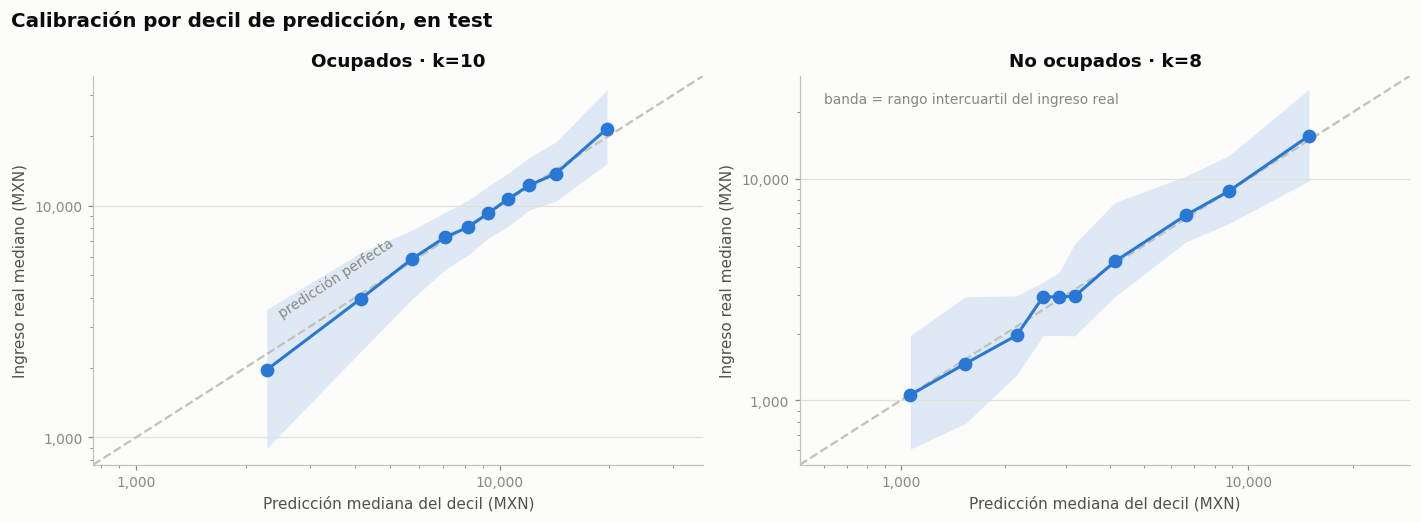

In [20]:
# Calibración: ¿el modelo acierta en todo el rango o sólo en el centro?
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, seg in zip(axes, SEGMENTOS):
    d = datos[seg]
    te_m = ~d["es_train"]
    t = pd.DataFrame({"pred": d["pred_test"], "real": d["y_pesos"][te_m], "w": d["w"][te_m]})
    t["decil"] = pd.qcut(t["pred"], 10, labels=False, duplicates="drop")
    g = t.groupby("decil")
    x = np.array([wquantile(s["pred"], .5, s["w"]) for _, s in g])
    y = np.array([wquantile(s["real"], .5, s["w"]) for _, s in g])
    lo = np.array([wquantile(s["real"], .25, s["w"]) for _, s in g])
    hi = np.array([wquantile(s["real"], .75, s["w"]) for _, s in g])
    lim = [min(x.min(), lo.min()) * .85, max(x.max(), hi.max()) * 1.15]
    ax.plot(lim, lim, color=AXIS, linestyle="--", linewidth=1.5)
    ax.fill_between(x, lo, hi, color=SERIES[0], alpha=.14, linewidth=0)
    ax.plot(x, y, color=SERIES[0], marker="o")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.xaxis.set_major_formatter(FMT_MILES); ax.yaxis.set_major_formatter(FMT_MILES)
    ax.set_title(f"{seg} · k={K_FINAL[seg]}")
    ax.set_xlabel("Predicción mediana del decil (MXN)")
    ax.set_ylabel("Ingreso real mediano (MXN)")
axes[0].annotate("predicción perfecta", (0.30, 0.38), xycoords="axes fraction",
                 color=MUTED, fontsize=9, rotation=33)
axes[1].annotate("banda = rango intercuartil del ingreso real", (0.04, 0.93),
                 xycoords="axes fraction", color=MUTED, fontsize=9)
fig.suptitle("Calibración por decil de predicción, en test", x=0.01, ha="left",
             fontsize=13, fontweight="semibold")
fig.tight_layout()
guardar(fig, "03_calibracion")
print("La curva sobre la diagonal en los extremos es el achatamiento típico de un modelo de media/mediana:\n"
      "sobreestima en la cola baja y subestima en la alta. §04 lo atiende con regresión cuantil.")

---
## 10. Save

| File | Content |
|---|---|
| `split_upm.csv` | the `upm` → train/test map (written in §2). **Notebook 04 must read this, not re-split.** |
| `features_ocupados.json` | the frozen list, each feature with its user-facing question |
| `features_no_ocupados.json` | same, for the non-worker model |
| `seleccion_v3.json` | curves, ceilings, stability counts, test metrics — the audit trail |


In [21]:
ARCHIVOS = {"Ocupados": "features_ocupados.json", "No ocupados": "features_no_ocupados.json"}
for seg in SEGMENTOS:
    payload = {
        "segmento": seg,
        "ruteo": "tiene_trabajo_principal == 1" if seg == "Ocupados" else "tiene_trabajo_principal == 0",
        "k": len(FEATURES[seg]),
        "features": FEATURES[seg],
        "formulario": [{"orden": i + 1, "variable": c, "pregunta": PREGUNTAS.get(c, ""),
                        "estabilidad": int(estabilidad[seg].get(c, -1)),
                        "importancia": round(float(importancias[seg].get(c, float("nan"))), 5)}
                       for i, c in enumerate(FEATURES[seg])],
        "overrides": [b for b in bitacora if b["segmento"] == seg],
        "target": {"columna": TARGET, "transformacion": "log",
                   "objetivo": "regression_l1 → mediana condicional",
                   "retransformacion": "exp(), sin smearing"},
        "metricas_test": resultados[seg],
        "pool_completo": podados[seg],
        "techo_cv_train": techos[seg],
    }
    (PROC_DIR / ARCHIVOS[seg]).write_text(json.dumps(payload, indent=2, ensure_ascii=False),
                                          encoding="utf-8")
    print(f"OK  {ARCHIVOS[seg]}  · k={len(FEATURES[seg])}")

auditoria = {
    "origen": "03_feature_selection.ipynb",
    "split": {"archivo": "split_upm.csv", "agrupado_por": "upm", "test_size": TEST_SIZE,
              "semilla": SEMILLA, "upm_train": len(upm_train), "upm_test": len(upm_test)},
    "parametros": {"N_FOLDS": N_FOLDS, "K_OBJETIVO": K_OBJETIVO, "K_GRID": K_GRID,
                   "UMBRAL_REDUNDANCIA": UMBRAL_REDUNDANCIA,
                   "TOLERANCIA_CURVA": TOLERANCIA_CURVA,
                   "SEMILLAS_ESTABILIDAD": SEMILLAS_ESTABILIDAD, "modelo": PARAMS},
    "por_segmento": {
        seg: {"pool_inicial": len(pools[seg]), "tras_poda": len(podados[seg]),
              "rodilla": rodillas[seg], "k_curva": K_FINAL[seg],
              "k_final": len(FEATURES[seg]), "features": FEATURES[seg],
              "overrides": [b for b in bitacora if b["segmento"] == seg],
              "techo_cv": techos[seg], "curva": curvas[seg].to_dict("records"),
              "redundantes_descartadas": descartes_red[seg].to_dict("records"),
              "estabilidad": estabilidad[seg][estabilidad[seg] > 0].to_dict(),
              "metricas_test": resultados[seg]}
        for seg in SEGMENTOS},
    "siguiente_paso": "04_modeling.ipynb — lee split_upm.csv y features_*.json; pipeline, "
                      "screening de familias, tuning, regresión cuantil e intervalos",
}
(PROC_DIR / "seleccion_v3.json").write_text(json.dumps(auditoria, indent=2, ensure_ascii=False,
                                                      default=str), encoding="utf-8")
print("OK  seleccion_v3.json")
print(f"OK  {len(list(FIG_DIR.glob('03_*.png')))} figuras")

OK  features_ocupados.json  · k=10
OK  features_no_ocupados.json  · k=7
OK  seleccion_v3.json
OK  5 figuras


In [22]:
for seg in SEGMENTOS:
    print(f"\n{'=' * 78}\n{seg.upper()}  —  {len(FEATURES[seg])} preguntas  ·  "
          f"MdAPE en test {resultados[seg]['corta']['MdAPE']:.1f}%  ·  "
          f"{resultados[seg]['corta']['pct_20']:.0f}% dentro de ±20%\n{'=' * 78}")
    for i, c in enumerate(FEATURES[seg], 1):
        est = estabilidad[seg].get(c, -1)
        marca = "+" if est < 0 else (" " if est >= len(SEMILLAS_ESTABILIDAD) else "!")
        print(f"{marca}{i:>3}. {c:<26} {PREGUNTAS.get(c, '')[:70]}")
    print("   (+ = entró por sustitución en §8.5, ! = no apareció en todas las semillas)")


OCUPADOS  —  10 preguntas  ·  MdAPE en test 30.8%  ·  34% dentro de ±20%
   1. horas_trabajadas           ¿Cuántas horas trabajaste la semana pasada?
!  2. formalidad                 ¿Tu trabajo te da IMSS/ISSSTE y prestaciones?
   3. cve_entidad                Estado de residencia — de la ubicación o del código postal
   4. anios_escolaridad          ¿Cuál es el último grado que aprobaste? (nivel + grado)
   5. sinco_grupo                ¿A cuál de estos 10 grupos se parece más tu ocupación?
   6. posicion_ocupacion         En tu trabajo, ¿eres empleado, patrón, trabajas por tu cuenta o sin pa
   7. es_jefe_hogar              ¿Eres la persona principal responsable de tu hogar?
+  8. sector_agrupado            ¿En qué sector trabajas? (8 opciones)
!  9. es_mujer                   ¿Cuál es tu sexo?
+ 10. tam_empresa_grupo          ¿Cuántas personas trabajan donde trabajas tú?
   (+ = entró por sustitución en §8.5, ! = no apareció en todas las semillas)

NO OCUPADOS  —  7 preguntas  ·  

---
## Summary

The split is frozen in `split_upm.csv`, and the two feature lists are frozen in `features_*.json` with the
question text attached, so the form and the model cannot drift apart.

**What notebook 04 inherits**

- `split_upm.csv` — read it; do not call `GroupShuffleSplit` again. A second split silently invalidates
  every number above.
- `features_ocupados.json` / `features_no_ocupados.json` — the `X` columns, per segment.
- Target treatment: `log`, L1 / quantile, `exp()` back-transform, no smearing.
- The test metrics above are the baseline to beat. Tuning should improve on them; if it does not, the
  honest report is that the untuned model was already at the ceiling of what these features support.

**Caveats to carry forward**

1. The curve was measured with one fixed set of hyper-parameters. A heavily tuned model can shift the knee
   slightly — worth re-checking once §04 has a tuned configuration, on train only.
2. Permutation importance splits credit between correlated survivors. §6 pruned the obvious pairs at
   V > 0.80; pairs below the threshold still share credit.
3. Calibration flattens at both tails. That is expected for a median model and is the main argument for
   shipping an interval rather than a point.
